In [1]:
import pandas as pd

# Path to the CSVs generated by sn-trackeval
df_baseline = pd.read_csv(r"C:\Users\jelle\Documents\TUEindhoven\Master\Thesis\development\tracklet_splitter_scratch\evaluation\SNPT\baseline\pedestrian_summary.txt", sep=r'\s+').T
df_gta = pd.read_csv(r"C:\Users\jelle\Documents\TUEindhoven\Master\Thesis\development\tracklet_splitter_scratch\evaluation\SNPT\gta\pedestrian_summary.txt", sep=r'\s+').T
df_reid = pd.read_csv(r"C:\Users\jelle\Documents\TUEindhoven\Master\Thesis\development\tracklet_splitter_scratch\evaluation\SNPT\reid_splitter\pedestrian_summary.txt", sep=r'\s+').T
df_rule_merger = pd.read_csv(r"C:\Users\jelle\Documents\TUEindhoven\Master\Thesis\development\tracklet_splitter_scratch\evaluation\SNPT\rule_tracklet_merger\pedestrian_summary.txt", sep=r'\s+').T
df_xgboost = pd.read_csv(r"C:\Users\jelle\Documents\TUEindhoven\Master\Thesis\development\tracklet_splitter_scratch\evaluation\SNPT\xgboost\pedestrian_summary.txt", sep=r'\s+').T
df_transformer = pd.read_csv(r"C:\Users\jelle\Documents\TUEindhoven\Master\Thesis\development\tracklet_splitter_scratch\evaluation\SNPT\transformer\pedestrian_summary.txt", sep=r'\s+').T

# Create a comparison table
comparison = pd.concat([df_baseline, df_gta, df_reid, df_rule_merger, df_xgboost, df_transformer], axis=1)
comparison.columns = ['baseline', 'GTA', 'ReID Splitter', 'Rule Merger', 'XGBOOST', 'Transformer']

critical_metrics = ['HOTA', 'AssA', 'DetA', 'IDF1', 'IDSW', 'IDTP', 'IDFP' , 'IDs', 'GT_IDs']
final_view = comparison.loc[critical_metrics]

final_view

,baseline,GTA,ReID Splitter,Rule Merger,XGBOOST,Transformer
HOTA,83.408,86.258,83.620,88.209,88.920,88.025
AssA,74.349,79.500,74.730,83.144,84.502,82.813
DetA,93.608,93.618,93.604,93.603,93.589,93.587
IDF1,83.762,89.368,83.796,91.965,92.955,91.758
IDSW,1521.000,1598.000,1511.000,1309.000,1232.000,1292.000
IDTP,397764.000,424388.000,397918.000,436709.000,441409.000,435725.000
IDFP,76674.000,50051.000,76503.000,37712.000,33012.000,38696.000
IDs,1693.000,1179.000,1734.000,1107.000,1138.000,1100.000
GT_IDs,1016.000,1016.000,1016.000,1016.000,1016.000,1016.000


Best Validation AUC: 0.9407 at round 122
Final Train AUC: 0.9971
Final Validation AUC: 0.9403
Gap at the end: 0.0568


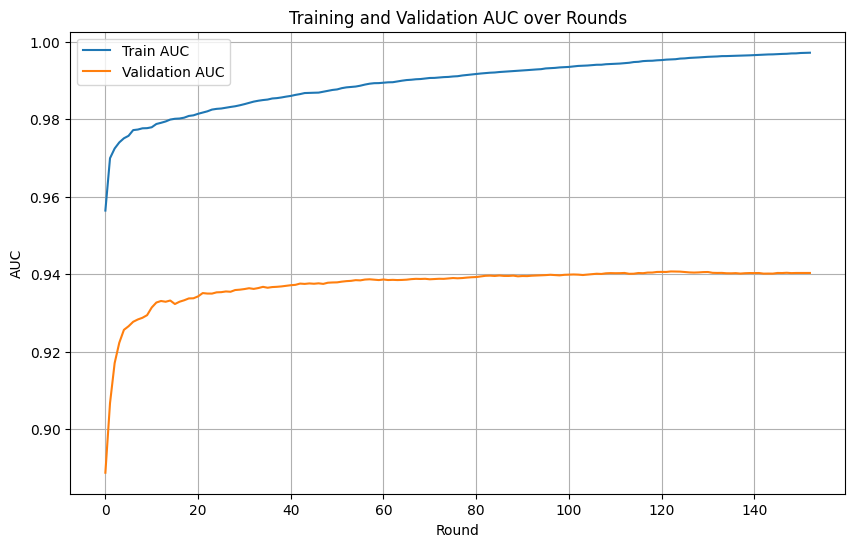

In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv(r'C:\Users\jelle\Documents\TUEindhoven\Master\Thesis\development\tracklet_splitter_scratch\train_data\weights\xgboost\training_log.csv')

import matplotlib.pyplot as plt

# Plotting the AUC curves
plt.figure(figsize=(10, 6))
plt.plot(df['round'], df['train_auc'], label='Train AUC')
plt.plot(df['round'], df['val_auc'], label='Validation AUC')
plt.xlabel('Round')
plt.ylabel('AUC')
plt.title('Training and Validation AUC over Rounds')
plt.legend()
plt.grid(True)
plt.savefig('auc_curves.png')

# Finding the best validation AUC
best_val_auc = df['val_auc'].max()
best_round = df.loc[df['val_auc'].idxmax(), 'round']
final_train_auc = df.iloc[-1]['train_auc']
final_val_auc = df.iloc[-1]['val_auc']

print(f"Best Validation AUC: {best_val_auc:.4f} at round {best_round}")
print(f"Final Train AUC: {final_train_auc:.4f}")
print(f"Final Validation AUC: {final_val_auc:.4f}")
print(f"Gap at the end: {final_train_auc - final_val_auc:.4f}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   epoch       36 non-null     int64  
 1   train_loss  36 non-null     float64
 2   train_auc   36 non-null     float64
 3   val_loss    36 non-null     float64
 4   val_auc     36 non-null     float64
 5   lr          36 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 1.8 KB
None
   epoch  train_loss  train_auc  val_loss   val_auc      lr
0      1    0.910044   0.763903  0.914438  0.783450  0.0005
1      2    0.884878   0.786032  0.895668  0.787099  0.0005
2      3    0.875814   0.791725  0.909599  0.786523  0.0005
3      4    0.874504   0.791620  0.890799  0.794818  0.0005
4      5    0.869738   0.797958  0.870234  0.800473  0.0005

--- Summary ---
Best Validation AUC: 0.8877 at index 20
Corresponding Training AUC: 0.8858
Best Validation Loss: 0.7271 at index 20


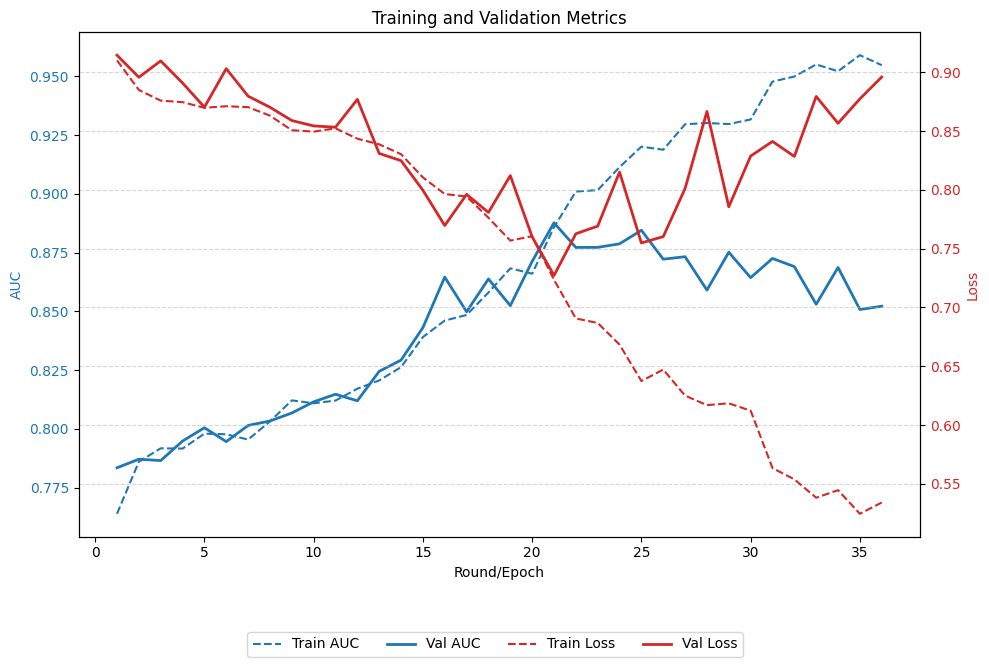

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the training log
df = pd.read_csv(r"C:\Users\jelle\Documents\TUEindhoven\Master\Thesis\development\tracklet_splitter_scratch\weights\transformer_w_team\training_log.csv")

# Display basic info and first few rows to confirm structure
print(df.info())
print(df.head())

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot AUC
ax1.set_xlabel('Round/Epoch')
ax1.set_ylabel('AUC', color='tab:blue')
ax1.plot(df.iloc[:, 0], df['train_auc'], label='Train AUC', color='tab:blue', linestyle='--')
ax1.plot(df.iloc[:, 0], df['val_auc'], label='Val AUC', color='tab:blue', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Check if 'loss' columns exist for a secondary axis
if 'train_loss' in df.columns and 'val_loss' in df.columns:
    ax2 = ax1.twinx()
    ax2.set_ylabel('Loss', color='tab:red')
    ax2.plot(df.iloc[:, 0], df['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
    ax2.plot(df.iloc[:, 0], df['val_loss'], label='Val Loss', color='tab:red', linewidth=2)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4)
else:
    ax1.legend(loc='best')

plt.title('Training and Validation Metrics')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('training_analysis_plot.png')

# Identify best round based on validation AUC
best_idx = df['val_auc'].idxmax()
best_row = df.loc[best_idx]

print("\n--- Summary ---")
print(f"Best Validation AUC: {best_row['val_auc']:.4f} at index {best_idx}")
print(f"Corresponding Training AUC: {best_row['train_auc']:.4f}")
if 'val_loss' in df.columns:
    print(f"Best Validation Loss: {df['val_loss'].min():.4f} at index {df['val_loss'].idxmin()}")

{'best_val_auc': np.float64(0.8876572675670201), 'best_auc_epoch': np.int64(21), 'min_val_loss': np.float64(0.7271328516923256), 'min_loss_epoch': np.int64(21), 'final_train_auc': np.float64(0.9547098887965176), 'final_val_auc': np.float64(0.8521761216100723), 'final_train_loss': np.float64(0.5340538958271781), 'final_val_loss': np.float64(0.8959087363282161), 'lr': np.float64(0.00025)}


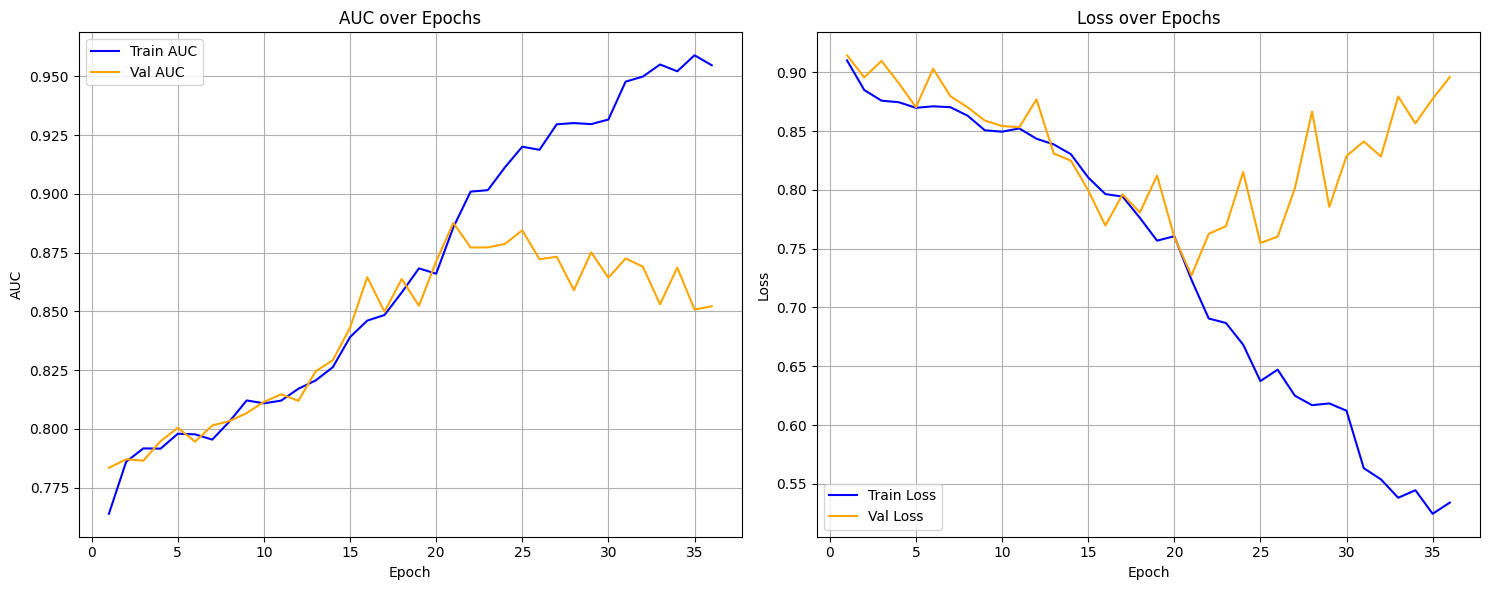

In [6]:
import matplotlib.pyplot as plt

# 1. Plot Training and Validation Metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# AUC Plot
ax1.plot(df['epoch'], df['train_auc'], label='Train AUC', color='blue')
ax1.plot(df['epoch'], df['val_auc'], label='Val AUC', color='orange')
ax1.set_title('AUC over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('AUC')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(df['epoch'], df['train_loss'], label='Train Loss', color='blue')
ax2.plot(df['epoch'], df['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')

# 2. Extract Key Statistics
best_auc_idx = df['val_auc'].idxmax()
best_auc_val = df.loc[best_auc_idx, 'val_auc']
best_auc_epoch = df.loc[best_auc_idx, 'epoch']

min_loss_idx = df['val_loss'].idxmin()
min_loss_val = df.loc[min_loss_idx, 'val_loss']
min_loss_epoch = df.loc[min_loss_idx, 'epoch']

final_epoch = df.iloc[-1]

stats = {
    "best_val_auc": best_auc_val,
    "best_auc_epoch": best_auc_epoch,
    "min_val_loss": min_loss_val,
    "min_loss_epoch": min_loss_epoch,
    "final_train_auc": final_epoch['train_auc'],
    "final_val_auc": final_epoch['val_auc'],
    "final_train_loss": final_epoch['train_loss'],
    "final_val_loss": final_epoch['val_loss'],
    "lr": final_epoch['lr']
}

print(stats)